# **PROYECTO INTEGRADOR**


**Integrantes:**
*   Betanzos Frias Kevin
*   Meléndez Chavero María Valeria
*   Romero de la Torre Kenia Michelle








**Inferencia no paramétrica aplicada a la industria musical.**

En este proyecto se analiza la relación entre la popularidad de los artistas y distintas características musicales utilizando herramientas de inferencia no paramétrica.






En esta sección importamos las librerías necesarias para el análisis estadístico.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Carga de bases de datos
 dataset de github

In [3]:
url = "https://raw.githubusercontent.com/valeria7melch-boop/artist_location/main/artist_location.csv"

artist_location = pd.read_csv(url)

In [4]:
print(artist_location.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13850 entries, 0 to 13849
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   artist_id  13850 non-null  object 
 1   latitude   13850 non-null  float64
 2   longitude  13850 non-null  float64
 3   artist     13850 non-null  object 
 4   location   13846 non-null  object 
dtypes: float64(2), object(3)
memory usage: 541.1+ KB
None


In [5]:
url="https://raw.githubusercontent.com/valeria7melch-boop/artist_tang/main/artist_tags.csv"
artist_tags=pd.read_csv(url)

In [6]:
print(artist_tags.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15375 entries, 0 to 15374
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   artist_id  15375 non-null  object
 1   mbtag      15375 non-null  object
dtypes: object(2)
memory usage: 240.4+ KB
None


In [7]:
url="https://raw.githubusercontent.com/valeria7melch-boop/artist_terms/main/artist_terms.csv"
artist_terms=pd.read_csv(url)

In [8]:
print(artist_terms.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12947 entries, 0 to 12946
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   artist_id  12947 non-null  object
 1   term       12947 non-null  object
dtypes: object(2)
memory usage: 202.4+ KB
None


In [9]:
url="https://raw.githubusercontent.com/valeria7melch-boop/features/main/audio_features.csv"
features=pd.read_csv(url)

In [10]:
print(features.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19664 entries, 0 to 19663
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   analysis_sample_rate  19664 non-null  int64  
 1   bit_rate              19664 non-null  int64  
 2   equal_loudness        19664 non-null  int64  
 3   length                19664 non-null  float64
 4   lossless              19664 non-null  int64  
 5   replay_gain           19664 non-null  float64
 6   sample_rate           19664 non-null  int64  
 7   codec                 19664 non-null  object 
 8   downmix               19664 non-null  object 
 9   md5_encoded           19664 non-null  object 
 10  track_id              19664 non-null  object 
 11  danceability          19664 non-null  float64
 12  femaleness            19664 non-null  float64
 13  acousticness          19664 non-null  float64
 14  aggressiveness        19664 non-null  float64
 15  electronicity      

In [11]:
url="https://raw.githubusercontent.com/valeria7melch-boop/genres/main/song_genres.csv"
genres=pd.read_csv(url)

In [12]:
print(genres.info)

<bound method DataFrame.info of                 track_id  main_genre
0     TRSZBVQ128F425D5B6        Rock
1     TRRJNCE128F9319E52         RnB
2     TRIZJQX128F1472163        Folk
3     TRBXBWB128F92F9F2B         Rap
4     TRFBZFH12903CBDABB  Electronic
...                  ...         ...
8411  TRHKNDN128F9320924       Blues
8412  TRGIYIR128F92DCDF1        Rock
8413  TRVFMDX128F42915F2        Punk
8414  TRLWOAY128F933A6A3        Rock
8415  TRVXQCP12903CA0817       Blues

[8416 rows x 2 columns]>


In [13]:
url="https://raw.githubusercontent.com/valeria7melch-boop/lyrics/main/song_lyrics.csv"
lyrics=pd.read_csv(url)

In [14]:
print(lyrics.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6803 entries, 0 to 6802
Columns: 101 entries, track_id to your
dtypes: float64(100), object(1)
memory usage: 5.2+ MB
None


Carga de datos desde Google Drive

In [15]:
from google.colab import drive
drive.mount('/content/drive')
summary = pd.read_csv(
    "/content/drive/MyDrive/Datos/summary.csv"
)



Mounted at /content/drive


In [16]:
print(summary.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   track_id                   20000 non-null  object 
 1   song_id                    20000 non-null  object 
 2   mode_confidence            20000 non-null  float64
 3   end_of_fade_in             20000 non-null  float64
 4   key_confidence             20000 non-null  float64
 5   energy                     20000 non-null  float64
 6   year                       20000 non-null  int64  
 7   duration                   20000 non-null  float64
 8   time_signature_confidence  20000 non-null  float64
 9   title                      20000 non-null  object 
 10  start_of_fade_out          20000 non-null  float64
 11  analysis_sample_rate       20000 non-null  int64  
 12  time_signature             20000 non-null  int64  
 13  tempo                      20000 non-null  flo

In [17]:
from google.colab import drive
drive.mount('/content/drive')
play = pd.read_csv(
    "/content/drive/MyDrive/Datos/song_play_count.csv"
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
print(play.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1517641 entries, 0 to 1517640
Data columns (total 3 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   user_id     1517641 non-null  int64 
 1   song_id     1517641 non-null  object
 2   play_count  1517641 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 34.7+ MB
None



#Fase 1:  Estadísica desciptiva y distribución empírica
Sea X una variable aleatoria continua para describir el comportamiento de la muestra se calculan medidas descriptivas como:

- mínimo,
- máximo,
- media,
- desviación estándar,
- cuantiles.

de probabilidad 0.01, 0.25, 0.50, 0.75 y 0.99 para la variable dependiente (Y) y las tres variables independientes (X1, X2, X3).




Mínimo

In [19]:
summary["artist_hotttnesss"].min()

0.0

In [20]:
summary["energy"].min()

0.0

In [21]:
features["danceability"].min()

3.00000096379e-14

In [22]:
features["acousticness"].min()

3.00000096379e-14

Maximo

In [23]:
summary["artist_hotttnesss"].max()

1.0825025567261235

In [24]:
summary["energy"].max()

0.0

In [25]:
features["danceability"].max()

0.999999880791

In [26]:
features["acousticness"].max()

0.999999880791

Media

In [27]:
summary["artist_hotttnesss"].mean()

np.float64(0.41579920479492155)

In [28]:
features["danceability"].mean()

np.float64(0.4360305205886615)

In [29]:
features["acousticness"].mean()

np.float64(0.3199084117940482)

In [30]:
summary["energy"].mean()

np.float64(0.0)

Desviación estandar

In [31]:
summary["artist_hotttnesss"].std()

0.11042460357598222

In [32]:
summary["energy"].std()

0.0

In [33]:
features["danceability"].std()

0.38396266166247006

In [34]:
features["acousticness"].std()

0.36134949991617676

Cuantiles de probabilidad 0.01

In [35]:
summary["artist_hotttnesss"].quantile(0.01)

np.float64(0.0)

In [36]:
summary["energy"].quantile(0.01)

np.float64(0.0)

In [37]:
features["danceability"].quantile(0.01)

np.float64(5.4355691909305e-12)

In [38]:
features["acousticness"].quantile(0.01)

np.float64(1.0534903802671e-08)

Cuantiles de probabilidad 0.25

In [39]:
summary["artist_hotttnesss"].quantile(0.25)

np.float64(0.3643096362490783)

In [40]:
summary["energy"].quantile(0.25)

np.float64(0.0)

In [41]:
features["danceability"].quantile(0.25)

np.float64(0.05679469741885)

In [42]:
features["acousticness"].quantile(0.25)

np.float64(0.011428546858975)

Cuantiles de probabilidad 0.50

In [43]:
summary["artist_hotttnesss"].quantile(0.50)

np.float64(0.4094280431885443)

In [44]:
summary["energy"].quantile(0.50)

np.float64(0.0)

In [45]:
features["danceability"].quantile(0.50)

np.float64(0.3284215331075)

In [46]:
features["acousticness"].quantile(0.50)

np.float64(0.12111913412799999)

Cuantiles de probabilidad 0.75

In [47]:
summary["artist_hotttnesss"].quantile(0.75)

np.float64(0.4690246250966762)

In [48]:
summary["energy"].quantile(0.75)

np.float64(0.0)

In [49]:
features["danceability"].quantile(0.75)

np.float64(0.86333990097075)

In [50]:
features["acousticness"].quantile(0.75)

np.float64(0.65281860530375)

Cuantiles de probabilidad 0.99

In [51]:
summary["artist_hotttnesss"].quantile(0.99)

np.float64(0.7247189729688089)

In [52]:
summary["energy"].quantile(0.99)

np.float64(0.0)

In [53]:
features["danceability"].quantile(0.99)

np.float64(0.99999930679785)

In [54]:
features["acousticness"].quantile(0.99)

np.float64(0.99774412035959)

La variable "energy" fue eliminada del análisis debido a que presenta valores iguales a cero en todas las observaciones por lo que no contiene información útil para el análisis estadístico ni para los modelos de inferencia no paramétrica implementados en este proyecto.

# Tabla de frecuencias.
Se construye una tabla de frecuencias para identificar los géneros musicales con mayor presencia dentro de la muestra analizada.


In [55]:
tabla_frecuencias = genres ["main_genre"].value_counts()

print(tabla_frecuencias)

main_genre
Rock          3413
Electronic     998
Pop            596
Jazz           566
Metal          449
RnB            444
Rap            431
Country        365
Reggae         323
Blues          263
Folk           202
Punk           127
Latin          120
World           70
New Age         49
Name: count, dtype: int64


# 2 Histogramas y densidad estimada

El histograma permite visualizar la distribución empírica de los datos observados.

La curva de densidad estimada proporciona una aproximación suavizada de la distribución poblacional de cada variable.

En esta sección se analizan gráficamente las variables:
- artist_hotttnesss
- danceability
- acousticness



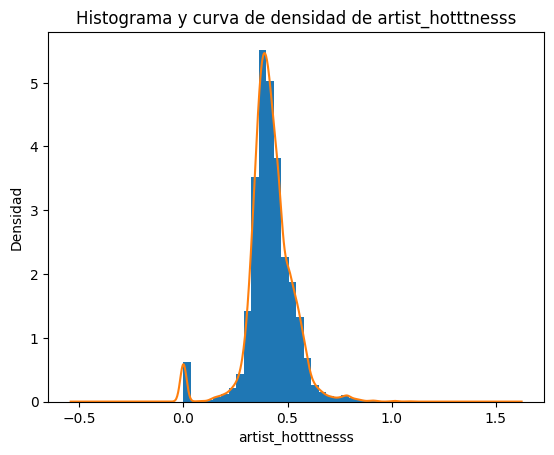

In [56]:
# Histograma
summary["artist_hotttnesss"].hist(
    bins=30,
    density=True
)

# Curva de densidad estimada
summary["artist_hotttnesss"].plot(
    kind="density"
)

# Títulos y etiquetas
plt.title("Histograma y curva de densidad de artist_hotttnesss")
plt.xlabel("artist_hotttnesss")
plt.ylabel("Densidad")

plt.show()

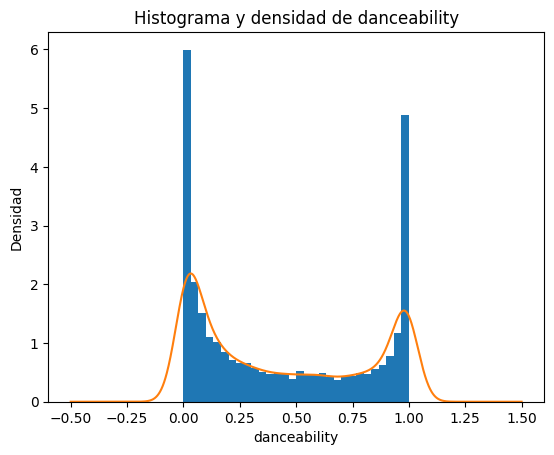

In [57]:
# Histograma
features["danceability"].hist(density=True, bins=30)

# Curva de densidad estimada
features["danceability"].plot(kind="density")

# Títulos
plt.title("Histograma y densidad de danceability")
plt.xlabel("danceability")
plt.ylabel("Densidad")

plt.show()

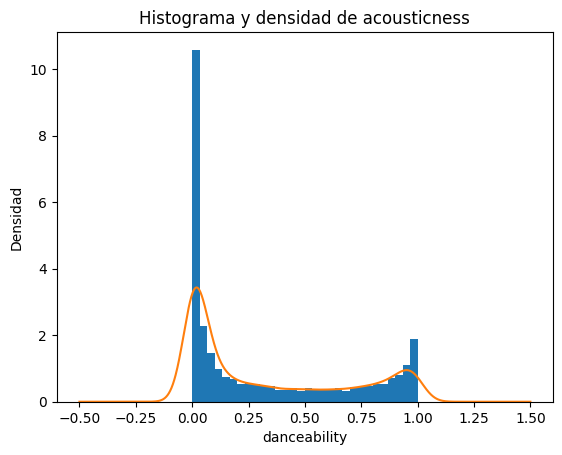

In [58]:
# Histograma
features["acousticness"].hist(density=True, bins=30)

# Curva de densidad estimada
features["acousticness"].plot(kind="density")

# Títulos
plt.title("Histograma y densidad de acousticness")
plt.xlabel("danceability")
plt.ylabel("Densidad")

plt.show()

# Función de distribución empírica

Sea $X_1, X_2, ..., X_n$ una muestra aleatoria.

La función de distribución empírica (FDE) se define como:

$F_n(x) = (1/n) Σ I(X_i ≤ x)$

donde I(.) es la función indicadora.

La FDE permite aproximar de manera no paramétrica la distribución acumulada poblacional utilizando únicamente la información muestral.

Grafica la función de distribución empírica (FDE) y sus bandas de confianza simultáneas
de DKW al 95 %.

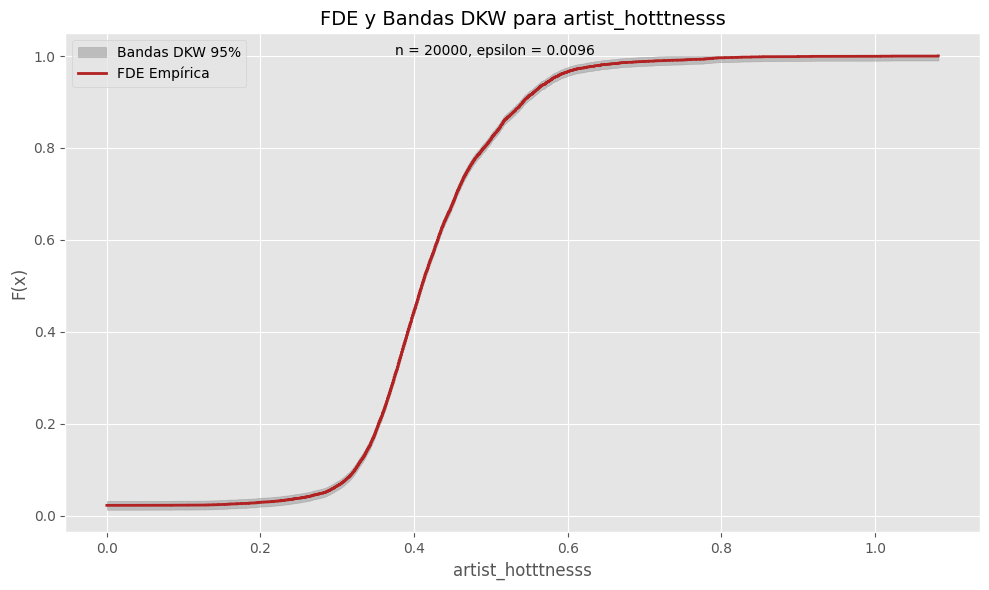

In [59]:


# Datos reales
muestra = summary["artist_hotttnesss"].dropna().values

# Parámetros
alpha = 0.05
n = len(muestra)

# Ordenar muestra
muestra = np.sort(muestra)

# Épsilon DKW
epsilon = np.sqrt(
    np.log(2 / alpha) / (2 * n)
)

# Grid
x_grid = np.linspace(
    np.min(muestra),
    np.max(muestra),
    1000
)

# Función de distribución empírica
fn_vals = np.mean(
    muestra[:, None] <= x_grid,
    axis=0
)

# Bandas DKW
u_band = np.minimum(
    fn_vals + epsilon,
    1
)

l_band = np.maximum(
    fn_vals - epsilon,
    0
)


# Visualización


plt.style.use('ggplot')

fig, ax = plt.subplots(
    figsize=(10, 6),
    dpi=100
)

# Bandas
ax.fill_between(
    x_grid,
    l_band,
    u_band,
    color='gray',
    alpha=0.4,
    label=f'Bandas DKW {(1-alpha)*100:.0f}%'
)

# FDE
ax.step(
    x_grid,
    fn_vals,
    where='post',
    color='firebrick',
    linewidth=2,
    label='FDE Empírica'
)

# Título
ax.set_title(
    "FDE y Bandas DKW para artist_hotttnesss",
    fontsize=14
)

# Información
plt.figtext(
    0.5,
    0.90,
    f"n = {n}, epsilon = {epsilon:.4f}",
    ha='center'
)

# Ejes
ax.set_xlabel("artist_hotttnesss")
ax.set_ylabel("F(x)")

# Leyenda
ax.legend()

plt.tight_layout()
plt.show()


# Bandas de confianza DKW

Se utilizan bandas simultáneas de confianza basadas en la desigualdad de Dvoretzky-Kiefer-Wolfowitz (DKW).

El margen de error está dado por:

$ε_n = sqrt[(1/(2n)) log(2/α)]$

Estas bandas permiten construir intervalos de confianza uniformes alrededor de la FDE con un nivel de confianza del 95%.


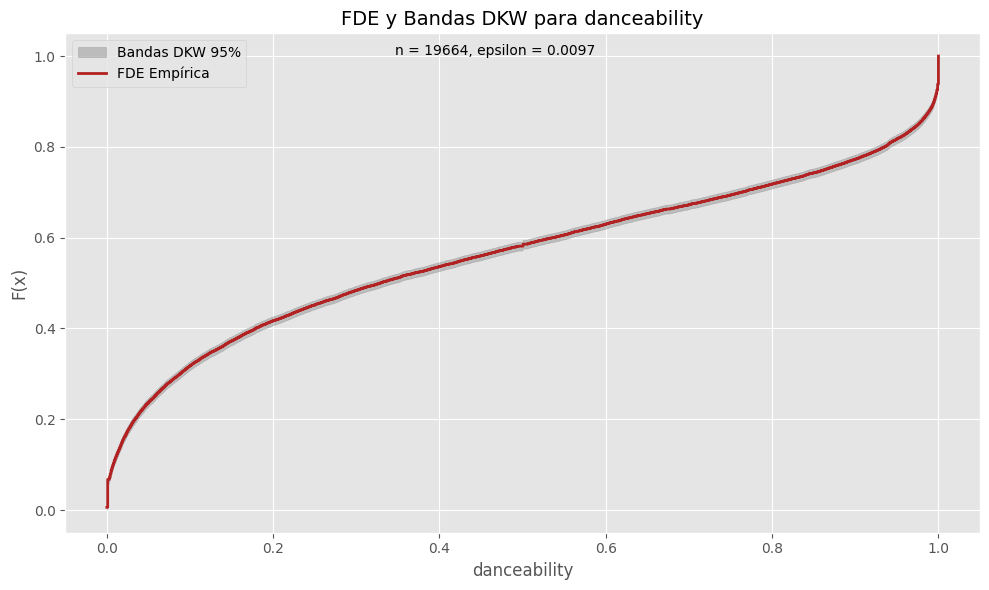

In [60]:


# Datos reales
muestra = features["danceability"].dropna().values

# Parámetros
alpha = 0.05
n = len(muestra)

# Ordenar muestra
muestra = np.sort(muestra)

# Épsilon DKW
epsilon = np.sqrt(
    np.log(2 / alpha) / (2 * n)
)

# Grid
x_grid = np.linspace(
    np.min(muestra),
    np.max(muestra),
    1000
)

# Función de distribución empírica
fn_vals = np.mean(
    muestra[:, None] <= x_grid,
    axis=0
)

# Bandas DKW
u_band = np.minimum(
    fn_vals + epsilon,
    1
)

l_band = np.maximum(
    fn_vals - epsilon,
    0
)

# Visualización


plt.style.use('ggplot')

fig, ax = plt.subplots(
    figsize=(10, 6),
    dpi=100
)

# Bandas DKW
ax.fill_between(
    x_grid,
    l_band,
    u_band,
    color='gray',
    alpha=0.4,
    label=f'Bandas DKW {(1-alpha)*100:.0f}%'
)

# FDE empírica
ax.step(
    x_grid,
    fn_vals,
    where='post',
    color='firebrick',
    linewidth=2,
    label='FDE Empírica'
)

# Título
ax.set_title(
    "FDE y Bandas DKW para danceability",
    fontsize=14
)

# Información adicional
plt.figtext(
    0.5,
    0.90,
    f"n = {n}, epsilon = {epsilon:.4f}",
    ha='center'
)

# Ejes
ax.set_xlabel("danceability")
ax.set_ylabel("F(x)")

# Leyenda
ax.legend()

plt.tight_layout()
plt.show()

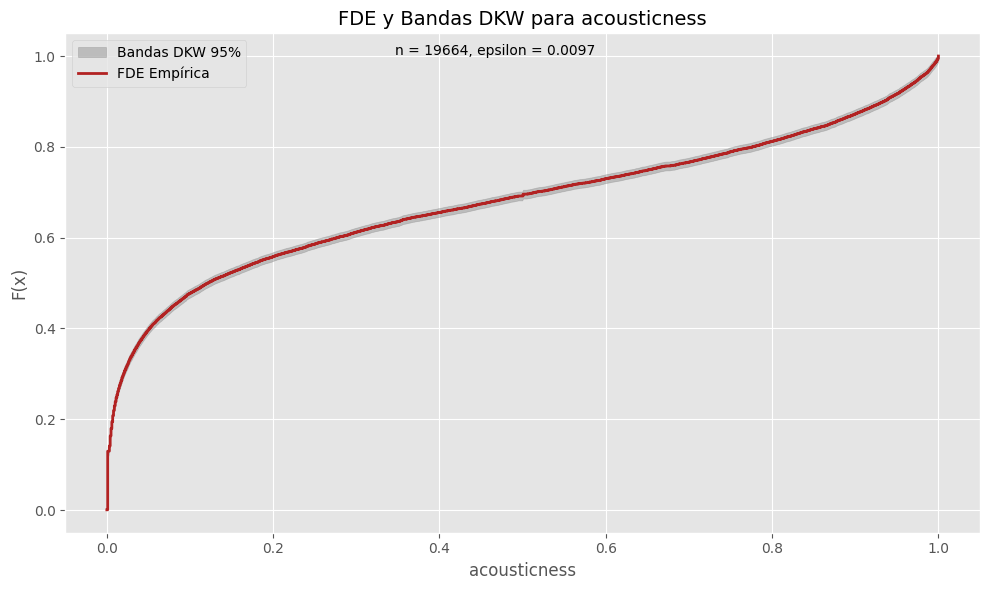

In [61]:


# Datos reales
muestra = features["acousticness"].dropna().values

# Parámetros
alpha = 0.05
n = len(muestra)

# Ordenar muestra
muestra = np.sort(muestra)

# Épsilon DKW
epsilon = np.sqrt(
    np.log(2 / alpha) / (2 * n)
)

# Grid
x_grid = np.linspace(
    np.min(muestra),
    np.max(muestra),
    1000
)

# Función de distribución empírica
fn_vals = np.mean(
    muestra[:, None] <= x_grid,
    axis=0
)

# Bandas DKW
u_band = np.minimum(
    fn_vals + epsilon,
    1
)

l_band = np.maximum(
    fn_vals - epsilon,
    0
)


# Visualización


plt.style.use('ggplot')

fig, ax = plt.subplots(
    figsize=(10, 6),
    dpi=100
)

# Bandas DKW
ax.fill_between(
    x_grid,
    l_band,
    u_band,
    color='gray',
    alpha=0.4,
    label=f'Bandas DKW {(1-alpha)*100:.0f}%'
)

# FDE empírica
ax.step(
    x_grid,
    fn_vals,
    where='post',
    color='firebrick',
    linewidth=2,
    label='FDE Empírica'
)

# Título
ax.set_title(
    "FDE y Bandas DKW para acousticness",
    fontsize=14
)

# Información adicional
plt.figtext(
    0.5,
    0.90,
    f"n = {n}, epsilon = {epsilon:.4f}",
    ha='center'
)

# Ejes
ax.set_xlabel("acousticness")
ax.set_ylabel("F(x)")

# Leyenda
ax.legend()

plt.tight_layout()
plt.show()


# Comparación de distribuciones por género musical

En esta sección se comparan las funciones de distribución empírica de artist_hotttnesss para los tres géneros musicales predominantes.

Esto permite visualizar diferencias en la distribución de popularidad entre géneros musicales.



→ Para la variable Y, gráfica  de la FDE agrupada por los tres géneros predo-
minantes (las tres curvas en un mismo plano) para visualizar las diferencias empíricas.

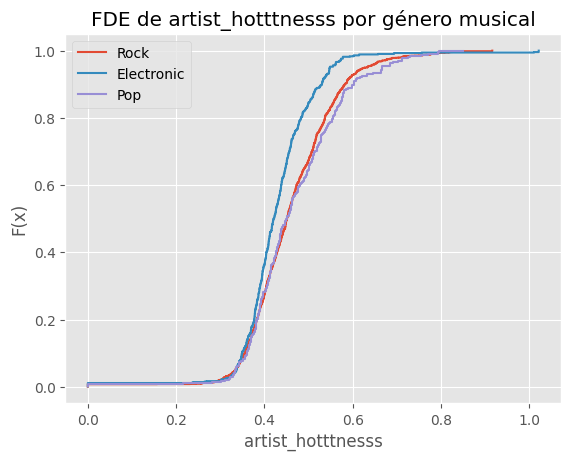

In [62]:
#  Combinar los DataFrames de summary y genres para crear 'datos'.
data = pd.merge(summary, genres, on='track_id', how='inner')

# Géneros predominantes
top_genres = ["Rock", "Electronic", "Pop"]

# Graficar FDE para cada género
for genre in top_genres:

    # Filtrar género
    subset = data[
        data["main_genre"] == genre
    ]["artist_hotttnesss"].dropna()

    # Ordenar datos
    x = np.sort(subset)

    # Tamaño de muestra
    n = len(x)

    # Función empírica
    fde = np.arange(1, n + 1) / n

    # Graficar
    plt.step(
        x,
        fde,
        where="post",
        label=genre
    )

# Títulos
plt.title("FDE de artist_hotttnesss por género musical")
plt.xlabel("artist_hotttnesss")
plt.ylabel("F(x)")

plt.legend()
plt.show()

# Parte 2


# Prueba de hipótesis para cuantiles

Se realiza una prueba de signos para evaluar si la mediana poblacional de artist_hotttnesss es igual a un valor de referencia m0.

Hipótesis:

$H_0$: Mediana(Y) = $m_0$

$H_1$: Mediana(Y) ≠ $m_0$

Para el umbral de popularidad elegimos el cuantil 0.75


In [63]:
# Variable Y
y = summary["artist_hotttnesss"].dropna()

# Umbral crítico m0
m0 = y.quantile(0.75)

print("m0 =", m0)

# Conteos
mayores = np.sum(y > m0)
menores = np.sum(y < m0)

# Total sin empates
n = mayores + menores

print("Mayores que m0:", mayores)
print("Menores que m0:", menores)

# Estadístico de prueba
z = (mayores - n/2) / np.sqrt(n/4)

print("\nEstadístico Z:", z)

# Regla de decisión al 95%
z_critico = 1.96

if abs(z) > z_critico:
    print("Se rechaza H0")
else:
    print("No se rechaza H0")

m0 = 0.4690246250966762
Mayores que m0: 4998
Menores que m0: 14999

Estadístico Z: -70.7230536144112
Se rechaza H0


La variable artist_hotttnesss presenta una media aproximada de 0.416 y desviación estándar de 0.110, mostrando una fuerte concentración alrededor de valores intermedios y una ligera asimetría positiva. Además, el histograma y la densidad estimada evidencian un soporte prácticamente acotado y un pico interior, características que no son consistentes con una distribución Normal o Exponencial. En consecuencia, una distribución Beta representa una alternativa paramétrica más adecuada para modelar la variable.


# Prueba Kolmogorov-Smirnov

La prueba de Kolmogorov-Smirnov compara la función de distribución empírica con una distribución teórica propuesta.

El estadístico KS se define como:

$D_n = sup |F_n(x)-F(x)|$

donde:
- $F_n(x)$ es la FDE,
- $F(x)$ es la distribución teórica.


In [64]:


# Datos
y = np.sort(summary["artist_hotttnesss"].dropna())

# Parámetros
mu = np.mean(y)
sigma = np.std(y)

# Tamaño muestra
n = len(y)

# Aproximación CDF normal
def normal_cdf(x, mu, sigma):

    z = (x - mu) / sigma

    t = 1 / (1 + 0.2316419 * np.abs(z))

    d = 0.3989423 * np.exp(-z**2 / 2)

    prob = 1 - d * (
        0.3193815 * t
        - 0.3565638 * t**2
        + 1.781478 * t**3
        - 1.821256 * t**4
        + 1.330274 * t**5
    )

    return np.where(z >= 0, prob, 1 - prob)

# FDE
fde = np.arange(1, n + 1) / n

# CDF normal
F = normal_cdf(y, mu, sigma)

# Estadístico KS
D_obs = np.max(np.abs(fde - F))

print("KS observado:", D_obs)

KS observado: 0.10090906209211081



# Prueba Anderson-Darling

La prueba Anderson-Darling evalúa la bondad de ajuste entre la distribución empírica observada y una distribución teórica propuesta.

Esta prueba da mayor peso a las colas de la distribución.


In [65]:
# Datos
y = np.sort(summary["artist_hotttnesss"].dropna())

# Parámetros estimados
mu = np.mean(y)
sigma = np.std(y)

# Tamaño muestra
n = len(y)

# Aproximación de la CDF normal
def normal_cdf(x, mu, sigma):

    z = (x - mu) / sigma

    t = 1 / (1 + 0.2316419 * np.abs(z))

    d = 0.3989423 * np.exp(-z**2 / 2)

    prob = 1 - d * (
        0.3193815 * t
        - 0.3565638 * t**2
        + 1.781478 * t**3
        - 1.821256 * t**4
        + 1.330274 * t**5
    )

    return np.where(z >= 0, prob, 1 - prob)

# Evaluar CDF teórica
F = normal_cdf(y, mu, sigma)

# Evitar log(0)
F = np.clip(F, 1e-10, 1 - 1e-10)

# Estadístico Anderson-Darling observado
A_obs = -n - np.mean(
    (2*np.arange(1, n+1)-1) *
    (
        np.log(F) +
        np.log(1 - F[::-1])
    )
)

print("AD observado:", A_obs)

# Bootstrap
B = 1000
A_boot = []

for i in range(B):

    # Simular bajo H0
    sample = np.random.normal(mu, sigma, n)

    sample = np.sort(sample)

    # Reestimar parámetros
    mu_b = np.mean(sample)
    sigma_b = np.std(sample)

    # CDF bootstrap
    F_b = normal_cdf(sample, mu_b, sigma_b)

    F_b = np.clip(F_b, 1e-10, 1 - 1e-10)

    # Estadístico bootstrap
    A_b = -n - np.mean(
        (2*np.arange(1, n+1)-1) *
        (
            np.log(F_b) +
            np.log(1 - F_b[::-1])
        )
    )

    A_boot.append(A_b)

# p-value bootstrap
p_value = np.mean(np.array(A_boot) >= A_obs)

print("p-value bootstrap:", p_value)

AD observado: 403.56980922596995
p-value bootstrap: 0.0



# Prueba Cramér-von Mises

La prueba Cramér-von Mises mide la discrepancia global entre la función de distribución empírica y la distribución teórica propuesta.


In [66]:


# Datos
y = np.sort(summary["artist_hotttnesss"].dropna())

# Parámetros estimados
mu = np.mean(y)
sigma = np.std(y)

# Tamaño muestra
n = len(y)

# Aproximación de la CDF normal
def normal_cdf(x, mu, sigma):

    z = (x - mu) / sigma

    t = 1 / (1 + 0.2316419 * np.abs(z))

    d = 0.3989423 * np.exp(-z**2 / 2)

    prob = 1 - d * (
        0.3193815 * t
        - 0.3565638 * t**2
        + 1.781478 * t**3
        - 1.821256 * t**4
        + 1.330274 * t**5
    )

    return np.where(z >= 0, prob, 1 - prob)

# Evaluar CDF teórica
F = normal_cdf(y, mu, sigma)

# Estadístico observado Cramér-von Mises
W_obs = (
    1 / (12 * n)
    +
    np.sum(
        (
            F -
            (2*np.arange(1, n+1)-1)/(2*n)
        )**2
    )
)

print("CvM observado:", W_obs)

# Bootstrap
B = 1000
W_boot = []

for i in range(B):

    # Simular bajo H0
    sample = np.random.normal(mu, sigma, n)

    sample = np.sort(sample)

    # Reestimar parámetros
    mu_b = np.mean(sample)
    sigma_b = np.std(sample)

    # CDF bootstrap
    F_b = normal_cdf(sample, mu_b, sigma_b)

    # Estadístico bootstrap
    W_b = (
        1 / (12 * n)
        +
        np.sum(
            (
                F_b -
                (2*np.arange(1, n+1)-1)/(2*n)
            )**2
        )
    )

    W_boot.append(W_b)

# p-value bootstrap
p_value = np.mean(np.array(W_boot) >= W_obs)

print("p-value bootstrap:", p_value)

CvM observado: 60.187621269522786
p-value bootstrap: 0.0



# Prueba de Wilcoxon-Mann-Whitney

Se comparan los niveles de popularidad entre los géneros Rock y Electronic mediante una prueba no paramétrica basada en rangos.

Hipótesis:

$H_0$: Ambas poblaciones tienen la misma distribución.

$H_1$: Las distribuciones son diferentes.


Aíslamos las observaciones correspondientes a los dos géneros musicales
predominantes que fueron Rock y Electronic

In [67]:
rock_electronic = data[
    data["main_genre"].isin(["Rock", "Electronic"])
]

In [68]:
print(rock_electronic.head())

              track_id             song_id  mode_confidence  end_of_fade_in  \
5   TRMLWWT128F14635AE  SOUQSEL12D02192BCC            0.711           1.489   
7   TRSUIZZ128F428EA82  SOYVRGA12A8C139DBA            0.544           0.206   
9   TRFYCKC128F92DE66B  SOUJLIR12AAF3B49B5            0.000           3.634   
11  TRQSYMQ128E0795772  SOHFEBN12A67ADBCE4            0.576           0.194   
13  TRMUQZK128F9312AFC  SOCILMC12AB01821F7            0.439           0.148   

    key_confidence  energy  year   duration  time_signature_confidence  \
5            0.716     0.0  1973  196.41424                      0.501   
7            0.610     0.0  2007  236.06812                      0.437   
9            0.000     0.0  1969  168.72444                      0.009   
11           0.677     0.0  2000  287.86893                      0.424   
13           0.314     0.0  1984  244.74077                      0.670   

                 title  ...  analysis_sample_rate  time_signature    tempo  \
5 


# Bootstrap para estimación de p-value

Se utiliza Bootstrap para aproximar la distribución del estadístico de prueba bajo la hipótesis nula mediante remuestreo con reemplazo.


In [69]:


# Datos de cada género
rock = data[
    data["main_genre"] == "Rock"
]["artist_hotttnesss"].dropna()

electronic = data[
    data["main_genre"] == "Electronic"
]["artist_hotttnesss"].dropna()

# Tamaños muestrales
n1 = len(rock)
n2 = len(electronic)

# Combinar datos
combined = np.concatenate([rock, electronic])

# Ranks
ranks = pd.Series(combined).rank()

# Suma de ranks grupo Rock
R1 = np.sum(ranks[:n1])

# Estadístico U
U1 = R1 - n1*(n1+1)/2

print("U observado:", U1)

# Aproximación normal
mu_U = n1*n2/2

sigma_U = np.sqrt(
    n1*n2*(n1+n2+1)/12
)

# Estadístico Z
Z = (U1 - mu_U) / sigma_U

print("Z:", Z)

# Regla de decisión al 5%
if abs(Z) > 1.96:
    print("Se rechaza H0")
else:
    print("No se rechaza H0")

U observado: 1051214.5
Z: 8.245008339818213
Se rechaza H0


In [70]:

# Datos de cada género
rock = data[
    data["main_genre"] == "Rock"
]["artist_hotttnesss"].dropna().values

electronic = data[
    data["main_genre"] == "Electronic"
]["artist_hotttnesss"].dropna().values

# Tamaños
n1 = len(rock)
n2 = len(electronic)

# Combinar
combined = np.concatenate([rock, electronic])

# Ranks
ranks = pd.Series(combined).rank()

# Suma de ranks Rock
R1 = np.sum(ranks[:n1])

# Estadístico U observado
U_obs = R1 - n1*(n1+1)/2

print("U observado:", U_obs)

# Bootstrap bajo H0
B = 1000

U_boot = []

for i in range(B):

    # Re-muestreo bajo H0
    sample1 = np.random.choice(
        combined,
        size=n1,
        replace=True
    )

    sample2 = np.random.choice(
        combined,
        size=n2,
        replace=True
    )

    # Combinar bootstrap
    boot_combined = np.concatenate(
        [sample1, sample2]
    )

    # Ranks bootstrap
    boot_ranks = pd.Series(
        boot_combined
    ).rank()

    # Suma de ranks bootstrap
    R1_boot = np.sum(
        boot_ranks[:n1]
    )

    # Estadístico bootstrap
    U_bootstrap = (
        R1_boot
        - n1*(n1+1)/2
    )

    U_boot.append(U_bootstrap)

# p-value bootstrap


U_boot = np.array(U_boot)

p_value = np.mean(
    np.abs(U_boot - np.mean(U_boot))
    >=
    np.abs(U_obs - np.mean(U_boot))
)

print("p-value bootstrap:", p_value)

U observado: 1051214.5
p-value bootstrap: 0.0



# Correlación de Spearman

El coeficiente de Spearman mide asociación monotónica entre dos variables utilizando rangos.

Su expresión es:

$ρ_s = 1 - [6 Σ d_i²] / [n(n²-1)]$

Coeficiente entre la variable Y y cada una de las tres variables independientes ($ X_2$, $X_3$).





In [71]:
# Unir por track_id
data_spearman2 = pd.merge(
    summary[["track_id", "artist_hotttnesss"]],
    features[["track_id", "danceability"]],
    on="track_id",
    how="inner"
).dropna()

Y2  = data_spearman2["artist_hotttnesss"].values
X2  = data_spearman2["danceability"].values
n   = len(Y2)

# Ranks
rank_Y  = pd.Series(Y2).rank().values
rank_X2 = pd.Series(X2).rank().values

# Diferencias
d = rank_Y - rank_X2

# Spearman observado
rho_X2 = 1 - (6 * np.sum(d**2)) / (n * (n**2 - 1))
print("Spearman Y vs X2:", rho_X2)

# Bootstrap por permutación bajo H0
B = 1000
rho_boot2 = []

for i in range(B):

    X2_perm = np.random.permutation(X2)

    rank_X2_perm = pd.Series(X2_perm).rank().values

    d_boot = rank_Y - rank_X2_perm

    rho_b = 1 - (6 * np.sum(d_boot**2)) / (n * (n**2 - 1))

    rho_boot2.append(rho_b)

# p-value
p_value_X2 = np.mean(np.abs(rho_boot2) >= np.abs(rho_X2))

print("p-value bootstrap Y vs X2:", p_value_X2)

Spearman Y vs X2: 0.02993045803975003
p-value bootstrap Y vs X2: 0.0


In [82]:
# Unir por track_id
data_spearman3 = pd.merge(
    summary[["track_id", "artist_hotttnesss"]],
    features[["track_id", "acousticness"]],
    on="track_id",
    how="inner"
).dropna()

Y3  = data_spearman3["artist_hotttnesss"].values
X3  = data_spearman3["acousticness"].values
n   = len(Y3)

# Ranks
rank_Y  = pd.Series(Y3).rank().values
rank_X3 = pd.Series(X3).rank().values

# Diferencias
d = rank_Y - rank_X3

# Spearman observado
rho_X3 = 1 - (6 * np.sum(d**2)) / (n * (n**2 - 1))
print("Spearman Y vs X3:", rho_X3)

# Bootstrap por permutación bajo H0
B = 1000
rho_boot3 = []

for i in range(B):

    X3_perm = np.random.permutation(X3)

    rank_X3_perm = pd.Series(X3_perm).rank().values

    d_boot = rank_Y - rank_X3_perm

    rho_b = 1 - (6 * np.sum(d_boot**2)) / (n * (n**2 - 1))

    rho_boot3.append(rho_b)

# p-value
p_value_X3 = np.mean(np.abs(rho_boot3) >= np.abs(rho_X3))

print("p-value bootstrap Y vs X3:", p_value_X3)

Spearman Y vs X3: -0.02661276572105553
p-value bootstrap Y vs X3: 0.001



# Bootstrap para Spearman

Se utiliza un procedimiento de remuestreo/permutación para aproximar la distribución del coeficiente de Spearman bajo independencia.


Prueba de hipótesis
para evaluar empíricamente si existe asociación estadística en cada par de variables.  p-values
utilizando Bootstrap.

$H_0=ps=0$ VS $H_1=p=1$

In [73]:
# Variables
Y = summary["artist_hotttnesss"]
X2 = features["danceability"]

# Limpiar NA
data2 = pd.DataFrame({
    "Y": Y,
    "X2": X2
}).dropna()

Y2 = data2["Y"]
X2 = data2["X2"]

# Ranks
rank_Y = Y2.rank()
rank_X2 = X2.rank()

# Diferencias
d = rank_Y - rank_X2

# Tamaño
n = len(d)

# Correlación observada
rho_obs = 1 - (
    6*np.sum(d**2)
) / (
    n*(n**2 - 1)
)

print("Spearman observado:", rho_obs)

# Bootstrap/permutación
B = 1000

rho_boot = []

for i in range(B):

    X_perm = np.random.permutation(X2)

    rank_X_perm = pd.Series(X_perm).rank()

    d_boot = rank_Y - rank_X_perm

    rho_b = 1 - (
        6*np.sum(d_boot**2)
    ) / (
        n*(n**2 - 1)
    )

    rho_boot.append(rho_b)

# p-value
p_value = np.mean(
    np.abs(rho_boot)
    >=
    np.abs(rho_obs)
)

print("p-value bootstrap:", p_value)

Spearman observado: 0.007731870636515148
p-value bootstrap: 0.273


In [74]:
# Variables
Y = summary["artist_hotttnesss"]
X3 = features["acousticness"]

# Limpiar NA
data3 = pd.DataFrame({
    "Y": Y,
    "X3": X3
}).dropna()

Y3 = data3["Y"]
X3 = data3["X3"]

# Ranks
rank_Y = Y3.rank()
rank_X3 = X3.rank()

# Diferencias
d = rank_Y - rank_X3

# Tamaño
n = len(d)

# Correlación observada
rho_obs = 1 - (
    6*np.sum(d**2)
) / (
    n*(n**2 - 1)
)

print("Spearman observado:", rho_obs)

# Bootstrap/permutación
B = 1000

rho_boot = []

for i in range(B):

    X_perm = np.random.permutation(X3)

    rank_X_perm = pd.Series(X_perm).rank()

    d_boot = rank_Y - rank_X_perm

    rho_b = 1 - (
        6*np.sum(d_boot**2)
    ) / (
        n*(n**2 - 1)
    )

    rho_boot.append(rho_b)

# p-value
p_value = np.mean(
    np.abs(rho_boot)
    >=
    np.abs(rho_obs)
)

print("p-value bootstrap:", p_value)

Spearman observado: -0.0027371485977711885
p-value bootstrap: 0.696


# Fase 3: Regresión no paramétrica

En esta sección se implementa el estimador de Nadaraya-Watson para modelar la relación entre artist_hotttnesss y las variables explicativas.

A diferencia de la regresión lineal clásica, este método no supone una forma funcional específica.


Estimador de Nadaraya-Watson

El estimador de Nadaraya-Watson aproxima la esperanza condicional:

$m(x)=E(Y|X=x)$

mediante promedios ponderados por funciones kernel.



Kernel Gaussiano

La función kernel asigna pesos mayores a observaciones cercanas al punto de estimación.

En este caso se utiliza el kernel Gaussiano:

$K(u)=exp(-u²/2)$


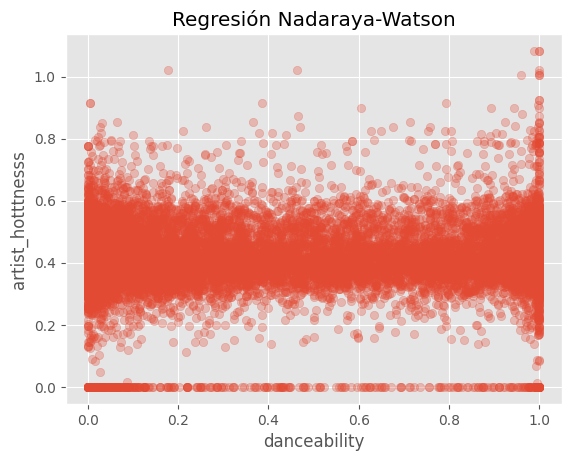

In [75]:



# FUNCIÓN KERNEL GAUSSIANO


def kernel_gaussiano(u):

    return np.exp(-0.5 * u**2)


# ESTIMADOR NADARAYA-WATSON



def nadaraya_watson(
    x_point,
    X,
    Y,
    h_bandwidth
):


    # Distancia estandarizada


    u = (
        X - x_point
    ) / h_bandwidth


    # Pesos kernel

    pesos = kernel_gaussiano(u)

    # Suma de pesos


    suma_pesos = np.sum(pesos)


    # Evitar división entre cero


    if suma_pesos == 0:

        return np.mean(Y)


    # Promedio ponderado


    estimacion = np.sum(
        pesos * Y
    ) / suma_pesos

    return estimacion


# UNIR DATASETS


datos = pd.merge(
    features,
    summary,
    on="track_id",
    how="inner"
)


# VARIABLES


X = datos["danceability"].values

Y = datos["artist_hotttnesss"].values


# ELIMINAR VALORES FALTANTES


mask = (
    ~np.isnan(X)
) & (
    ~np.isnan(Y)
)

X = X[mask]

Y = Y[mask]


# BANDWIDTH


h = 0.1


# GRID DE VALORES X


x_grid = np.linspace(
    np.min(X),
    np.max(X),
    200
)


# ESTIMACIONES


y_hat = []

for x in x_grid:

    # Estimar E(Y|X=x)

    estimacion = nadaraya_watson(
        x,
        X,
        Y,
        h
    )

    y_hat.append(estimacion)

# Convertir a arreglo numpy

y_hat = np.array(y_hat)


# GRÁFICA


# Datos originales

plt.scatter(
    X,
    Y,
    alpha=0.3
)

# Curva Nadaraya-Watson

plt.plot(
    x_grid,
    y_hat,
    linewidth=3
)

# Títulos

plt.title(
    "Regresión Nadaraya-Watson"
)

plt.xlabel("danceability")

plt.ylabel("artist_hotttnesss")

plt.show()

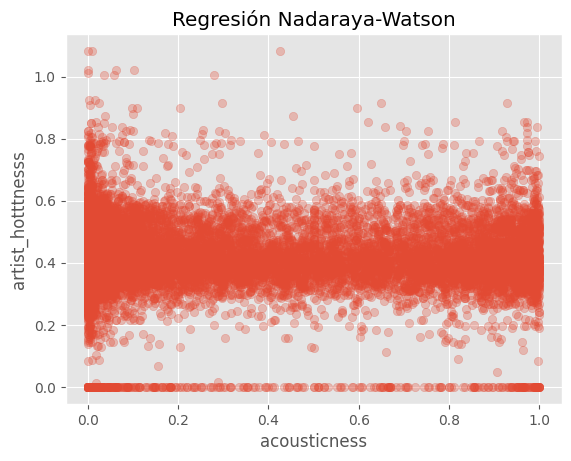

In [76]:



# FUNCIÓN KERNEL GAUSSIANO


def kernel_gaussiano(u):

    return np.exp(-0.5 * u**2)


# ESTIMADOR NADARAYA-WATSON


def nadaraya_watson(
    x_point,
    X,
    Y,
    h_bandwidth
):


    # Distancia estandarizada


    u = (
        X - x_point
    ) / h_bandwidth


    # Pesos kernel


    pesos = kernel_gaussiano(u)


    # Suma de pesos


    suma_pesos = np.sum(pesos)

    # Evitar división entre cero


    if suma_pesos == 0:

        return np.mean(Y)


    # Promedio ponderado


    estimacion = np.sum(
        pesos * Y
    ) / suma_pesos

    return estimacion


# UNIR DATASETS


datos = pd.merge(
    features,
    summary,
    on="track_id",
    how="inner"
)


# VARIABLES


X = datos["acousticness"].values

Y = datos["artist_hotttnesss"].values


# ELIMINAR VALORES FALTANTES


mask = (
    ~np.isnan(X)
) & (
    ~np.isnan(Y)
)

X = X[mask]

Y = Y[mask]


# BANDWIDTH


h = 0.1


# GRID DE VALORES X


x_grid = np.linspace(
    np.min(X),
    np.max(X),
    200
)


# ESTIMACIONES


y_hat = []

for x in x_grid:

    # Estimar E(Y|X=x)

    estimacion = nadaraya_watson(
        x,
        X,
        Y,
        h
    )

    y_hat.append(estimacion)

# Convertir a arreglo numpy

y_hat = np.array(y_hat)


# GRÁFICA


# Datos originales

plt.scatter(
    X,
    Y,
    alpha=0.3
)

# Curva Nadaraya-Watson

plt.plot(
    x_grid,
    y_hat,
    linewidth=3
)

# Títulos

plt.title(
    "Regresión Nadaraya-Watson"
)

plt.xlabel("acousticness")

plt.ylabel("artist_hotttnesss")

plt.show()

Graficas de curvas de regresión resultantes superpuestas en
diagramas de dispersión.

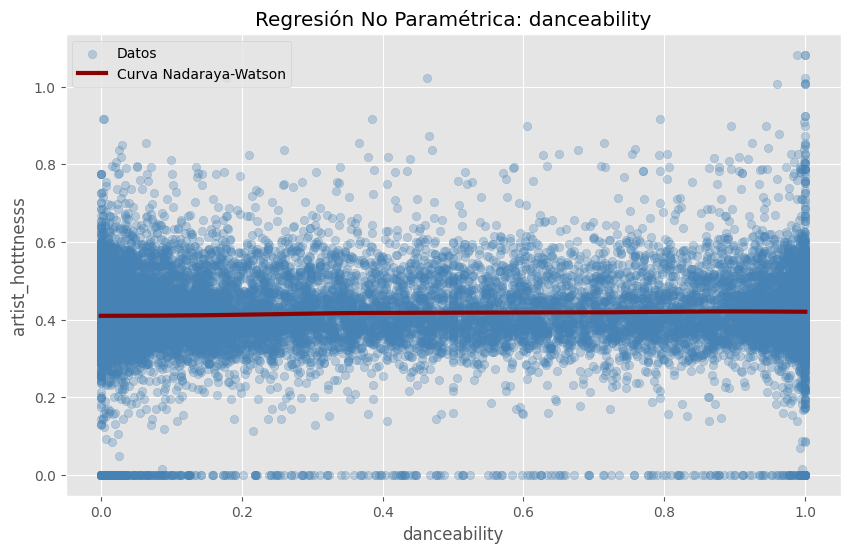

In [77]:



# KERNEL GAUSSIANO


def kernel_gaussiano(u):

    return np.exp(-0.5 * u**2)

# NADARAYA-WATSON


def nadaraya_watson(
    x_point,
    X,
    Y,
    h_bandwidth
):

    u = (
        X - x_point
    ) / h_bandwidth

    pesos = kernel_gaussiano(u)

    suma_pesos = np.sum(pesos)

    if suma_pesos == 0:

        return np.mean(Y)

    return np.sum(
        pesos * Y
    ) / suma_pesos


# UNIR BASES


datos = pd.merge(
    features,
    summary,
    on="track_id",
    how="inner"
)

# VARIABLES

X = datos["danceability"].values

Y = datos["artist_hotttnesss"].values


# ELIMINAR NA
mask = (
    ~np.isnan(X)
) & (
    ~np.isnan(Y)
)

X = X[mask]

Y = Y[mask]


# BANDWIDTH


h = 0.1

# GRID

x_grid = np.linspace(
    np.min(X),
    np.max(X),
    200
)

# ESTIMACIONES

y_hat = []

for x in x_grid:

    y_hat.append(
        nadaraya_watson(
            x,
            X,
            Y,
            h
        )
    )


# GRÁFICA
plt.figure(figsize=(10,6))

# Dispersión azul
plt.scatter(
    X,
    Y,
    alpha=0.3,
    color="steelblue",
    label="Datos"
)

# Curva roja
plt.plot(
    x_grid,
    y_hat,
    linewidth=3,
    color="darkred",
    label="Curva Nadaraya-Watson"
)

plt.title(
    "Regresión No Paramétrica: danceability"
)

plt.xlabel("danceability")

plt.ylabel("artist_hotttnesss")

plt.legend()

plt.show()

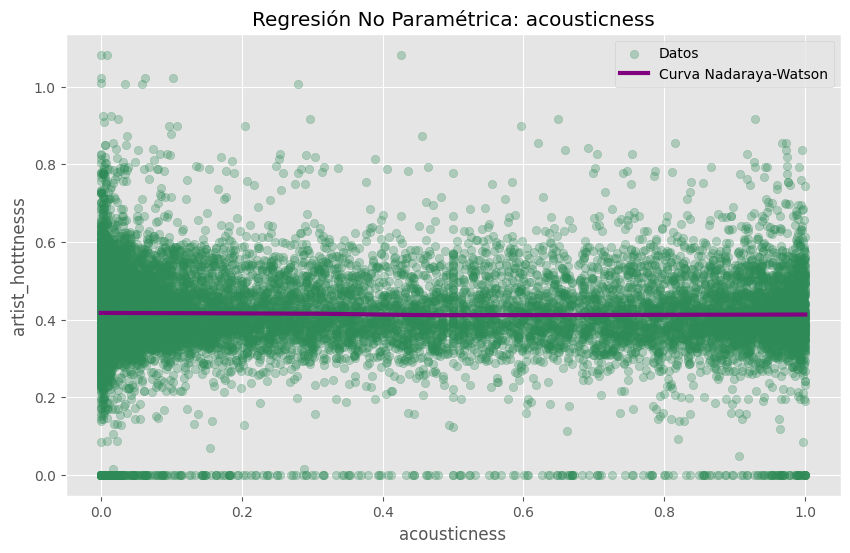

In [78]:



# KERNEL GAUSSIANO

def kernel_gaussiano(u):

    return np.exp(-0.5 * u**2)

# NADARAYA-WATSON

def nadaraya_watson(
    x_point,
    X,
    Y,
    h_bandwidth
):

    u = (
        X - x_point
    ) / h_bandwidth

    pesos = kernel_gaussiano(u)

    suma_pesos = np.sum(pesos)

    if suma_pesos == 0:

        return np.mean(Y)

    return np.sum(
        pesos * Y
    ) / suma_pesos

# UNIR BASES

datos = pd.merge(
    features,
    summary,
    on="track_id",
    how="inner"
)

# VARIABLES

X = datos["acousticness"].values

Y = datos["artist_hotttnesss"].values


# ELIMINAR NA

mask = (
    ~np.isnan(X)
) & (
    ~np.isnan(Y)
)

X = X[mask]

Y = Y[mask]


# BANDWIDTH

h = 0.1


# GRID

x_grid = np.linspace(
    np.min(X),
    np.max(X),
    200
)


# ESTIMACIONES


y_hat = []

for x in x_grid:

    y_hat.append(
        nadaraya_watson(
            x,
            X,
            Y,
            h
        )
    )


# GRÁFICA


plt.figure(figsize=(10,6))

# Dispersión verde
plt.scatter(
    X,
    Y,
    alpha=0.3,
    color="seagreen",
    label="Datos"
)

# Curva morada
plt.plot(
    x_grid,
    y_hat,
    linewidth=3,
    color="purple",
    label="Curva Nadaraya-Watson"
)

plt.title(
    "Regresión No Paramétrica: acousticness"
)

plt.xlabel("acousticness")

plt.ylabel("artist_hotttnesss")

plt.legend()

plt.show()


# Error Cuadrático Medio (MSE)
El MSE mide el error promedio entre los valores observados y las predicciones del modelo.

Su expresión es:

MSE = $(1/n) Σ (Y_i - Ŷ_i)^2$

Valores pequeños indican mejor capacidad predictiva.

In [79]:



# KERNEL


def kernel_gaussiano(u):

    return np.exp(-0.5 * u**2)


# NADARAYA-WATSON


def nadaraya_watson(
    x_point,
    X,
    Y,
    h_bandwidth
):

    u = (
        X - x_point
    ) / h_bandwidth

    pesos = kernel_gaussiano(u)

    suma_pesos = np.sum(pesos)

    if suma_pesos == 0:

        return np.mean(Y)

    return np.sum(
        pesos * Y
    ) / suma_pesos

# UNIR BASES


datos = pd.merge(
    features,
    summary,
    on="track_id",
    how="inner"
)

# VARIABLES

X = datos["danceability"].values

Y = datos["artist_hotttnesss"].values

# ELIMINAR NA

mask = (
    ~np.isnan(X)
) & (
    ~np.isnan(Y)
)

X = X[mask]

Y = Y[mask]

# BANDWIDTH

h = 0.1

# PREDICCIONES
Y_hat = []

for x in X:

    pred = nadaraya_watson(
        x,
        X,
        Y,
        h
    )

    Y_hat.append(pred)

Y_hat = np.array(Y_hat)


# MSE

mse_danceability = np.mean(
    (Y - Y_hat)**2
)

print(
    "MSE danceability:",
    mse_danceability
)

MSE danceability: 0.012272297934921617


In [80]:



# KERNEL


def kernel_gaussiano(u):

    return np.exp(-0.5 * u**2)


# NADARAYA-WATSON


def nadaraya_watson(
    x_point,
    X,
    Y,
    h_bandwidth
):

    u = (
        X - x_point
    ) / h_bandwidth

    pesos = kernel_gaussiano(u)

    suma_pesos = np.sum(pesos)

    if suma_pesos == 0:

        return np.mean(Y)

    return np.sum(
        pesos * Y
    ) / suma_pesos


# UNIR BASES


datos = pd.merge(
    features,
    summary,
    on="track_id",
    how="inner"
)


# VARIABLES


X = datos["acousticness"].values

Y = datos["artist_hotttnesss"].values


# ELIMINAR NA


mask = (
    ~np.isnan(X)
) & (
    ~np.isnan(Y)
)

X = X[mask]

Y = Y[mask]


# BANDWIDTH


h = 0.1


# PREDICCIONES


Y_hat = []

for x in X:

    pred = nadaraya_watson(
        x,
        X,
        Y,
        h
    )

    Y_hat.append(pred)

Y_hat = np.array(Y_hat)


# MSE


mse_acousticness = np.mean(
    (Y - Y_hat)**2
)

print(
    "MSE acousticness:",
    mse_acousticness
)

MSE acousticness: 0.012288065433393934
